## TO DO
- Write up of models, parametrization, etc.


In [1]:
import socket
import sys
import os
import time
import importlib
from pathlib import Path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../src"))) #use this to be able to import local packages
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../../src"))) #use this to be able to import local packages
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../src"))) #use this to be able to import local packages
import numpy as np
import pandas as pd
import pickle
import pyarrow.parquet as pq
import utils.openkarst_network
importlib.reload(utils.openkarst_network)
from utils.openkarst_network import OpenKarstNetwork as OKN
import utils.conduits
importlib.reload(utils.conduits)
from utils.conduits import *
from utils.common import load_yaml, print_verbose, load_pickle, write_pickle
import openkarst
importlib.reload(openkarst)
from openkarst.network_generation import compute_conduit_lengths
from openkarst.models import FlowSimulation
from openkarst.visualization.openkarst_viewer import launch_openkarst_viewer
from scripts.openkarst.extract_steady_state_conditions import extract_steady_state_conditions
from utils.spring import outlet_flow, write_outlet_flow
import seaborn as sns
import matplotlib.pyplot as plt


In [39]:
#set up and load network
network_dir = 'conduits/networks/n_4'
nodes = pd.read_csv(f'{network_dir}/nodes.csv')
edges = pd.read_csv(f'{network_dir}/edges.csv')
nodes, edges = reset_node_ids(nodes, edges)
# network_dir = 'conduit_geometry_test/networks/straight_conduit_n62'
network = OKN(nodes = nodes, edges= edges, diameters = 0.5) 
network.load_cave_data()
network.extract_edge_coordinates()
network.extract_boundary_nodes()
network.extract_diffuse_inlets()
network.plot_3D_network(node_color = 'type')


### No Reservoir

In [22]:
save_path = "reservoir_test/no_reservoir"
adaptive_timesteps = True
steady_state = False 
output_interval = 100
dt_init = 1.0
dt_max = 10
t_max = 20000
inflow_type = 'constant'
head_type = 'constant'
inflow = 0.1
inflow_boundary = {network.diffuse_inlets: {'flow' : inflow/len(network.diffuse_inlets)}} # m^3/s
head_boundary = {network.outlets: {'head' : 0.001}}
# Setup flow simulation parameters
physical_properties = {
    'water_density': 1000,        # kg/m^3
    'gravity': 9.81,              # m/s^2
    'dynamic_viscosity': 0.001,   # Pa.s (kg/m.s)
    'geometry_channel': False,    # Channel geometry for analytical solutions (Default False)
    'channel_type': 'infinite',   # 'infinite' for infinitely wide channel, 'finite' for defined width
    'channel_width': 1.0,         # Width of the channel (only used if channel_type is 'finite')
}

solver_settings = {
    "relaxation_factor": 0.6,
    "max_iterations": 20,
    "picard_depth_tol": 1e-6,
    "ss_rel_l2tol": 1e-5,
}

simulation_settings = {
    'min_waterdepth': 1e-10,      # Minimum water depth (meters)
    'min_flowrate': 1e-10,        # Minimum flow rate (m^3/s)
    'courant': 0.8,               # Courant number
    'adaptive_timesteps': adaptive_timesteps,   # Use adaptive timestepping
    'dt_init': dt_init,             # Initial (or constant) timestep (seconds)
    'dt_max': dt_max,                # Maximum allowable time step
    'steady_state': steady_state,         # Steady-state (True) or transient (False)
    't_max': t_max,              # Maximum time for transient simulations (seconds)
    'print_info_interval': 1000,     # Print info every # time steps
}

output_settings = {
    'output_interval': output_interval,  # Output results every # time steps
    'time': True,
    'time_step_size': True,
    'flowrates': True,
    'water_depths': True,
    'l2_norms': True,
    'convergence_fails': True,
    'reynolds_numbers': True,
}

logging_settings = {
    'base_dir': save_path if save_path is not None else '.',
    'log_file': 'simulation.log'
}

# Compute conduit lengths using the utility function
cn_geometry = compute_conduit_lengths(network.geometry)

# Assign conduit properties
cn_geometry['throat.epsilon'] = 0.03 # Roughness height (m), default, if cn_params is not none, it will be updated

# Create flow network object
flow_network = FlowSimulation(cn_geometry,
                                physical_properties = physical_properties,
                                solver_settings = solver_settings,
                                simulation_settings = simulation_settings,
                                logging_settings = logging_settings)

# Set initial conditions-- empty
initial_Q = np.full(cn_geometry.Nt, 1e-5, dtype=float)   # Initial flows at each conduit (Nt throats)
initial_y = np.full(cn_geometry.Np, 1e-5, dtype=float)   # Initial depths at each conduit (Np pores)
flow_network.set_initial_conditions(initial_Q, initial_y)

# Set boundary conditions
for n in inflow_boundary.keys():
    if inflow_type == 'ramp':
        inflow_values = ('ramp', inflow_boundary[n]['flow_start'], inflow_boundary[n]['time_start'], inflow_boundary[n]['flow_end'], inflow_boundary[n]['time_end'])
    elif inflow_type == 'timeseries':
        inflow_values = ('timeseries', inflow_boundary[n]['time'], inflow_boundary[n]['flow'])
    elif inflow_type == 'constant':
        inflow_values = inflow_boundary[n]['flow']
    flow_network.set_inflow_BC(nodes = list(n), values = inflow_values)

for n in head_boundary.keys():
    if head_type == 'ramp':
        head_values = ('ramp', head_boundary[n]['head_start'], head_boundary[n]['time_start'], head_boundary[n]['head_end'], head_boundary[n]['time_end'])
    elif head_type == 'timeseries':
        head_values = ('timeseries', head_boundary[n]['time'], head_boundary[n]['head'])
    elif head_type == 'constant':
        head_values = head_boundary[n]['head']
    flow_network.set_waterdepth_BC(nodes = list(n), values = head_values)

# write input data to pkl for record keeping
input_data = {'nodes' : network.nodes, 'edges' : network.edges, 
            'point_inlets': network.point_inlets,
            'diffuse_inlets': network.diffuse_inlets,
            'lattice_inlets': getattr(network, 'lattice_inlets', None),
            'outlets': network.outlets,
            'cn_geometry' : cn_geometry, 
            'inflow_boundary' : inflow_boundary, 
            'head_boundary' : head_boundary, 
            'initial_depth' : initial_y, 
            'initial_flowrate' : initial_Q}

write_pickle(f'{save_path}/input_data.pkl', input_data)
#observation points at springs    
flow_network.set_observation_points(
    nodes=list(network.outlets),
    variables=["connected_abs_flowrate", "connected_net_flowrate"],
    interval=output_settings["output_interval"],
)
# Run simulation and store results

results = flow_network.run_simulation(desired_outputs = output_settings)


# Get observation data as DataFrame
obs_df = flow_network.get_observation_dataframe()
Q = results['flowrates']
y = results['water_depths']
t = results['time']
re = results['reynolds_numbers']
np.savez(f"{save_path}/results.npz", Q=Q, y=y, t=t, re=re)
obs_df.to_csv(f"{save_path}/observation_data.csv", index=False)

Timestep = 0, Time = 0.0, dt = 1.00e+00
Converged = True, Picard iterations = 14, convergence fails = 0
relL2(y) = 9.87e-01, relL2(Q) = 4.78e+00
Max Froude = 1.33
Max Re = 342.39 Avg Re = 98.73

[run_simulation] Not converged at time = 3.6
[run_simulation] Not converged at time = 5.2
[run_simulation] Not converged at time = 6.8
[run_simulation] Not converged at time = 8.4
[run_simulation] Not converged at time = 10.0
[run_simulation] Not converged at time = 11.5
[run_simulation] Not converged at time = 13.1
[run_simulation] Not converged at time = 14.6
[run_simulation] Not converged at time = 16.1
[run_simulation] Not converged at time = 17.6
[run_simulation] Not converged at time = 19.1
[run_simulation] Not converged at time = 20.6
Timestep = 1000, Time = 1011.3, dt = 1.00e+00
Converged = True, Picard iterations = 8, convergence fails = 12
relL2(y) = 4.48e-04, relL2(Q) = 5.23e-04
Max Froude = 1.88
Max Re = 363301.79 Avg Re = 145253.24

Timestep = 2000, Time = 2011.3, dt = 1.00e+00
Con

### Reservoir

In [4]:
recharge_df = pd.read_csv("reservoir_test/gaussian_pulse_short_spinup.csv")
recharge_timeseries = np.array(recharge_df.recharge)
recharge_time = np.array(recharge_df.time)

In [2]:
def run_reservoir_model(network, head_boundary, inflow_boundary, concentration_boundary, reservoirs, save_path, **params):
    adaptive_timesteps = True
    steady_state = params.get("steady_state", False) 
    output_interval = params.get('output_interval', 100)
    data_to_save = params.get('data_to_save', [])
    dt_init = 1.0
    dt_max = 10
    t_max = params.get('t_max', 0) 
    exchange_model = params.get('exchange_model', 'linear')
    observation_nodes = params.get('observation_nodes', list(network.outlets))
    # if recharge_time is None and t_max == 0: 
    #     raise ValueError("Need to have valid t_max or recharge timeseries")
    inflow_type = params.get('inflow_type', 'constant')
    head_type = params.get('head_type', 'constant')
    concentration_type = params.get('concentration_type', 'constant')
    transport = False if concentration_boundary is None or len(concentration_boundary) == 0 else True
    transport_settings = params.get('transport_settings', {})
    #reservoir setting!!


    # Setup flow simulation parameters
    physical_properties = {
        'water_density': 1000,        # kg/m^3
        'gravity': 9.81,              # m/s^2
        'dynamic_viscosity': 0.001,   # Pa.s (kg/m.s)
        'geometry_channel': False,    # Channel geometry for analytical solutions (Default False)
        'channel_type': 'infinite',   # 'infinite' for infinitely wide channel, 'finite' for defined width
        'channel_width': 1.0,         # Width of the channel (only used if channel_type is 'finite')
    }

    solver_settings = {
        "relaxation_factor": 0.6,
        "max_iterations": 20,
        "picard_depth_tol": 1e-6,
        "ss_rel_l2tol": 1e-5,
    }

    simulation_settings = {
        'min_waterdepth': 1e-10,      # Minimum water depth (meters)
        'min_flowrate': 1e-10,        # Minimum flow rate (m^3/s)
        'courant': 0.8,               # Courant number
        'adaptive_timesteps': adaptive_timesteps,   # Use adaptive timestepping
        'dt_init': dt_init,             # Initial (or constant) timestep (seconds)
        'dt_max': dt_max,                # Maximum allowable time step
        'steady_state': steady_state,         # Steady-state (True) or transient (False)
        't_max': t_max,              # Maximum time for transient simulations (seconds)
        'print_info_interval': 10000,     # Print info every # time steps
        "enable_transport": transport, #transport

    }

    output_settings = {
        'output_interval': output_interval,  # Output results every # time steps
        'time': True,
        'time_step_size': True,
        'flowrates': True,
        'water_depths': True,
        'l2_norms': True,
        'convergence_fails': True,
        'reynolds_numbers': True,
         "concentrations": True if transport else False,
         'velocities' : True
         

    }

    logging_settings = {
        'base_dir': save_path if save_path is not None else '.',
        'log_file': 'simulation.log'
    }

    # Compute conduit lengths using the utility function
    cn_geometry = compute_conduit_lengths(network.geometry)

    # Assign conduit properties
    cn_geometry['throat.epsilon'] = 0.03 # Roughness height (m), default, if cn_params is not none, it will be updated

    # Create flow network object
    flow_network = FlowSimulation(cn_geometry,
                                    physical_properties = physical_properties,
                                    solver_settings = solver_settings,
                                    simulation_settings = simulation_settings,
                                    transport_settings = transport_settings,
                                    logging_settings = logging_settings)

    # Set initial conditions-- empty
    initial_Q = np.full(cn_geometry.Nt, 0, dtype=float)   # Initial flows at each conduit (Nt throats)
    initial_y = np.full(cn_geometry.Np, 1e-3, dtype=float)   # Initial depths at each conduit (Np pores)
    initial_C = np.full(cn_geometry.Np, 0, dtype=float)   # Initial concentrations at each conduit (Np pores)
    flow_network.set_initial_conditions(initial_Q, initial_y)
    if transport:
        flow_network.set_initial_concentrations(initial_C)


    # Set boundary conditions
    for n in inflow_boundary.keys():
        if inflow_type == 'ramp':
            inflow_values = ('ramp', inflow_boundary[n]['flow_start'], inflow_boundary[n]['time_start'], inflow_boundary[n]['flow_end'], inflow_boundary[n]['time_end'])
        elif inflow_type == 'timeseries':
            inflow_values = ('timeseries', inflow_boundary[n]['time'], inflow_boundary[n]['flow'])
        elif inflow_type == 'constant':
            inflow_values = inflow_boundary[n]['flow']
        flow_network.set_inflow_BC(nodes = list(n), values = inflow_values)

    for n in head_boundary.keys():
        if head_type == 'ramp':
            head_values = ('ramp', head_boundary[n]['head_start'], head_boundary[n]['time_start'], head_boundary[n]['head_end'], head_boundary[n]['time_end'])
        elif head_type == 'timeseries':
            head_values = ('timeseries', head_boundary[n]['time'], head_boundary[n]['head'])
        elif head_type == 'constant':
            head_values = head_boundary[n]['head']
        flow_network.set_waterdepth_BC(nodes = list(n), values = head_values)

    """NOTE: This concentration boundary is currently in mass injection kg/s instead of mg/L"""
    for n in concentration_boundary.keys():
        if concentration_type == 'ramp':
            concentration_values = ('ramp', concentration_boundary[n]['concentration_start'], concentration_boundary[n]['time_start'], concentration_boundary[n]['concentration_end'], concentration_boundary[n]['time_end'])
        elif concentration_type == 'timeseries':
            concentration_values = ('timeseries', concentration_boundary[n]['time'], concentration_boundary[n]['concentration'])
        elif concentration_type == 'constant':
            concentration_values = concentration_boundary[n]['concentration']
        flow_network.set_mass_injection_BC(nodes = list(n), values = concentration_values, extrapolate = 'zero')

    #!!! Add reservoirs 
    for reservoir_node, reservoir in reservoirs.items():
        flow_network.add_reservoir(
                reservoir_node,
                reservoir['A'],
                reservoir['S_y'],
                reservoir['h_0'],
                reservoir['C'],
                recharge = reservoir['reservoir_recharge'],
                exchange_model = exchange_model
            )

    #write input data to pkl for record keeping
    input_data = {'nodes' : network.nodes, 'edges' : network.edges, 
                'point_inlets': network.point_inlets,
                'diffuse_inlets': network.diffuse_inlets,
                'lattice_inlets': getattr(network, 'lattice_inlets', None),
                'outlets': network.outlets,
                'cn_geometry' : cn_geometry, 
                'inflow_boundary' : inflow_boundary, 
                'head_boundary' : head_boundary, 
                'concentration_boundary' : concentration_boundary,
                'initial_depth' : initial_y, 
                'initial_flowrate' : initial_Q,
                'reservoirs' : reservoirs}

    #observation points at springs 
    spring_variables = ["connected_abs_flowrate", "connected_net_flowrate", "concentrations"] if transport else ["connected_abs_flowrate", "connected_net_flowrate"]   
    flow_network.set_observation_points(
        nodes=observation_nodes,
        variables=spring_variables,
        interval=output_settings["output_interval"],
    )
    flow_network.set_observation_points(
        nodes=list(reservoirs.keys()),
        variables=["reservoir_head", "reservoir_storage", "reservoir_exchange"],
        interval=output_settings["output_interval"]
    )
    # Run simulation and store results

    results = flow_network.run_simulation(desired_outputs = output_settings)

    # Get observation data as DataFrame

    obs_df = flow_network.get_observation_dataframe()
    saved_results = {}
    for data in data_to_save:
        if data == 'input_data':
            write_pickle(f'{save_path}/input_data.pkl', input_data)
        elif data == 'observation_data':
            obs_df.to_csv(f"{save_path}/observation_data.csv", index=False)
        else:
            try: 
                saved_results[data] = results[data]
            except KeyError:
                raise Warning(f"{data} not found")
    if saved_results:
        np.savez(f"{save_path}/results.npz", **saved_results)
    return flow_network, results

In [37]:
save_path = "reservoir_test/dupuit/straight_conduit/no_reservoir"
adaptive_timesteps = True
steady_state = False 
output_interval = 100
dt_init = 1.0
dt_max = 100
inflow_type = 'timeseries'
head_type = 'constant'
conduit_eta = 1
# fracture_eta = 0.33
matrix_eta = 1 - conduit_eta
reservoirs = {
    # 10 : {'A' : 1e3, 'S_y' : 0.15, 'h_0' : .001, 'C' : 1e-4, 'reservoir_recharge' : ('timeseries', recharge_time, recharge_timeseries*matrix_eta)},
    # 15: {'A' : 1e3, 'S_y' : 0.15, 'h_0' : 1, 'C' : 1e-2, 'reservoir_recharge' : ('timeseries', recharge_time, recharge_timeseries*fracture_eta)},
}
inflow_boundary = {network.inlets : {'flow' : recharge_timeseries * conduit_eta, 'time': recharge_time}} #{network.diffuse_inlets: {'flow' : 0.1/len(network.diffuse_inlets)}} # m^3/s
head_boundary = {network.outlets: {'head' : 0.001}}
t_max= recharge_time[-1]

#reservoir setting!!

flow_network, results = run_reservoir_model(network, head_boundary, inflow_boundary,
                                            reservoirs,
                                            save_path, 
                                            t_max = t_max,
                                            output_interval = 100, 
                                            data_to_save = ['input_data', 'observation_data', 'flowrates', 'reynolds_numbers', 'water_depths', 'time'], 
                                            observation_nodes = [network.inlets[0], network.outlets[0]],
                                            steady_state = steady_state,
                                            inflow_type = inflow_type,
                                            head_type = head_type)

Timestep = 0, Time = 0.0, dt = 1.00e+00
Converged = True, Picard iterations = 9, convergence fails = 0
relL2(y) = 4.42e-01, relL2(Q) = 1.00e+00
Max Froude = 0.95
Max Re = 1103.46 Avg Re = 82.64

Timestep = 10000, Time = 10005.0, dt = 1.00e+00
Converged = True, Picard iterations = 1, convergence fails = 0
relL2(y) = 1.41e-12, relL2(Q) = 2.52e-12
Max Froude = 1.33
Max Re = 152915.16 Avg Re = 131525.19

Timestep = 20000, Time = 20005.0, dt = 1.00e+00
Converged = True, Picard iterations = 1, convergence fails = 0
relL2(y) = 7.32e-17, relL2(Q) = 2.57e-15
Max Froude = 1.33
Max Re = 152915.16 Avg Re = 131525.19

Timestep = 30000, Time = 30005.0, dt = 1.00e+00
Converged = True, Picard iterations = 1, convergence fails = 0
relL2(y) = 2.77e-17, relL2(Q) = 2.56e-15
Max Froude = 1.33
Max Re = 152915.16 Avg Re = 131525.19

Timestep = 40000, Time = 40005.0, dt = 1.00e+00
Converged = True, Picard iterations = 1, convergence fails = 0
relL2(y) = 5.54e-17, relL2(Q) = 2.78e-15
Max Froude = 1.33
Max Re =

In [30]:
save_path = "reservoir_test/anastomotic_2/d=0.1/no_reservoir/pulse_only" #TODO: fix 
adaptive_timesteps = True
steady_state = False 
output_interval = 100
dt_init = 1.0
dt_max = 100
inflow_type = 'timeseries'
head_type = 'constant'
conduit_eta = 1
# fracture_eta = 0.33
matrix_eta = 1 - conduit_eta
reservoirs = {
    # 10 : {'A' : 1e6, 'S_y' : 0.15, 'h_0' : .001, 'C' : 1e-4, 'reservoir_recharge' : ('timeseries', recharge_time, recharge_timeseries*matrix_eta)},
    # 15: {'A' : 1e3, 'S_y' : 0.15, 'h_0' : 1, 'C' : 1e-2, 'reservoir_recharge' : ('timeseries', recharge_time, recharge_timeseries*fracture_eta)},
}
inflow_boundary = {network.inlets : {'flow' : recharge_timeseries * conduit_eta/len(network.inlets), 'time': recharge_time}} #{network.diffuse_inlets: {'flow' : 0.1/len(network.diffuse_inlets)}} # m^3/s
head_boundary = {network.outlets: {'head' : 0.001}}
concentration_boundary = {}

t_max= recharge_time[-1]

flow_network, results = run_reservoir_model(network, head_boundary, inflow_boundary,
                                            concentration_boundary,
                                            reservoirs,
                                            save_path, 
                                            t_max = t_max,
                                            output_interval = 100, 
                                            data_to_save = ['input_data', 'observation_data', 'flowrates', 'reynolds_numbers', 'water_depths', 'time'], 
                                            observation_nodes = list(network.inlets + network.outlets),
                                            steady_state = steady_state,
                                            inflow_type = inflow_type,
                                            head_type = head_type)

Timestep = 0, Time = 0.0, dt = 1.00e+00
Converged = True, Picard iterations = 20, convergence fails = 0
relL2(y) = 1.86e-01, relL2(Q) = 1.00e+00
Max Froude = 0.59
Max Re = 249.88 Avg Re = 48.08

[run_simulation] Not converged at time = 55.0
[run_simulation] Not converged at time = 78.0
[run_simulation] Not converged at time = 79.1
[run_simulation] Not converged at time = 83.8
[run_simulation] Not converged at time = 2674.2
[run_simulation] Not converged at time = 2675.2
[run_simulation] Not converged at time = 2678.2
[run_simulation] Not converged at time = 2684.2
[run_simulation] Not converged at time = 2688.2
[run_simulation] Not converged at time = 2691.2
[run_simulation] Not converged at time = 2697.2
[run_simulation] Not converged at time = 2698.2
[run_simulation] Not converged at time = 2700.2
[run_simulation] Not converged at time = 2701.2
[run_simulation] Not converged at time = 2705.2
[run_simulation] Not converged at time = 2717.2
[run_simulation] Not converged at time = 2734

KeyboardInterrupt: 

In [3]:
def calculate_pressurized_flowrate(d, dh_dl, Re = 2300): 
    """ Based on Darcy-Weisbach formulation for flow in a pressurized pipe. 
    Calculates max possible flowrate under laminar conditions (Re = 2300)
    Q = vA, where v is velocity calculated using D-W formulation
    Parameters: Conduit diameter (d), overall head gradient dh_dl (m/m), Reynolds number (Re)"""
    f = 64/Re
    v = np.sqrt((2*9.81*dh_dl*d)/f)
    A = np.pi*(d**2)/4
    Q = v*A
    return Q 

def calculate_head_gradient(nodes, inlet_d, inlet_flag = 'inlet', outlet_flag = 'outlet'): 
    """Calculates head gradient between inlet and outlet nodes of a network"""
    inlet_nodes = nodes[nodes['type'] == inlet_flag]
    outlet_nodes = nodes[nodes['type'] == outlet_flag]
    max_dh_dl = 0
    for inlet_node in inlet_nodes.itertuples():
        for outlet_node in outlet_nodes.itertuples():
            dh = inlet_node.z + inlet_d - outlet_node.z
            dl = np.linalg.norm(np.array([inlet_node.x - outlet_node.x, inlet_node.y - outlet_node.y]))
            dh_dl = dh/dl
            if np.abs(dh_dl) > np.abs(max_dh_dl):
                max_dh_dl = dh_dl
    return max_dh_dl

def calculate_pressurized_diameter(Q, dh_dl, Re = 2300): 
    """ Based on Darcy-Weisbach formulation for flow in a pressurized pipe. 
    Calculates max possible conduit diameter under laminar conditions (Re = 2300)
    Q = vA, where v is velocity calculated using D-W formulation
    Parameters: Flowrate (Q), overall head gradient dh_dl (m/m), Reynolds number (Re)"""
    f = 64/Re
    d = (4 * Q / np.pi * np.sqrt(f/(2*9.81*dh_dl)))**(2/5)
    return d
    

In [34]:
ds = np.array([0.01, 0.1, 1, 10])
gradients = []
for d in ds: 
    dhdl = calculate_head_gradient(nodes, inlet_d = d, inlet_flag = 'inlet', outlet_flag = 'outlet')
    gradients.append(dhdl)

In [23]:
#loop to rerun networks with higher runtime to see late-time tailing
index = {f'anastomotic_density_{n}' : f'conduits/networks/density_{n}' for n in [5 ,6,7]
         }
recharge = pd.read_csv("reservoir_test/gaussian_pulse_5_day.csv")
recharge_timeseries = np.array(recharge.recharge)
recharge_time = np.array(recharge.time)
Q_bf= 0.02
Q_peak = recharge_timeseries.max()


In [24]:
for network_name in index.keys():
    #set up and load network
    network_dir = index[network_name]
    nodes = pd.read_csv(f'{network_dir}/nodes.csv')
    edges = pd.read_csv(f'{network_dir}/edges.csv')
    nodes, edges = reset_node_ids(nodes, edges)
    #calculate head gradient for network
    dh_dl = calculate_head_gradient(nodes, inlet_d = 0.5, inlet_flag = 'inlet', outlet_flag = 'outlet')
    d_crit = np.round(calculate_pressurized_diameter(Q = Q_bf, dh_dl = dh_dl, Re = 2300), 3)
    #TODO finish updating this to account for different pressurization regimes
    d_unpressurized = np.round(calculate_pressurized_diameter(Q = Q_peak, dh_dl = dh_dl, Re = 100), 3)
    ds = {'unpressurized' : d_unpressurized * 1.1, 'partially_pressurized' : d_unpressurized * 0.9, 'fully_pressurized' : d_crit * 0.9}# unpressurized, partially pressurized, fully pressurized
    for regime, diameter in ds.items():
        save_path = f"reservoir_test/{network_name}/{regime}/no_reservoir"
        if os.path.exists(f"{save_path}/results.npz"):
            print(f"Results already exist for {save_path}, skipping...")
            continue
        network = OKN(nodes = nodes, edges= edges, diameters = diameter) 
        network.load_cave_data()
        network.extract_edge_coordinates()
        network.extract_boundary_nodes()
        network.extract_diffuse_inlets()
        adaptive_timesteps = True
        steady_state = False 
        output_interval = 100
        dt_init = 1.0
        dt_max = 100
        inflow_type = 'timeseries'
        head_type = 'constant'
        # concentration_type = 'timeseries'
        conduit_eta = 1
        # fracture_eta = 0.33
        matrix_eta = 1 - conduit_eta
        reservoirs = {
            # 10 : {'A' : 1e6, 'S_y' : 0.15, 'h_0' : .001, 'C' : 1e-4, 'reservoir_recharge' : ('timeseries', recharge_time, recharge_timeseries*matrix_eta)},
            # 15: {'A' : 1e3, 'S_y' : 0.15, 'h_0' : 1, 'C' : 1e-2, 'reservoir_recharge' : ('timeseries', recharge_time, recharge_timeseries*fracture_eta)},
        }
        inflow_boundary = {network.inlets : {'flow' : recharge_timeseries * conduit_eta/len(network.inlets), 'time': recharge_time}} #{network.diffuse_inlets: {'flow' : 0.1/len(network.diffuse_inlets)}} # m^3/s
        head_boundary = {network.outlets: {'head' : 0.001}}
        concentration_boundary = {}
        # concentration_boundary = {network.inlets : {'concentration' : 1 * np.ones(5), 'time' : np.arange(1000, 5001, 1000)}}
        t_max= recharge_time[-1]


        transport_settings = {
            "molecular_diffusivity": 1e-9,
            "alpha_l": 1.0,
            "decay_rate": 0.0,
            "transport_cfl": 0.5,
        }

        flow_network, results = run_reservoir_model(network, head_boundary, 
                                                    inflow_boundary, 
                                                    concentration_boundary,
                                                    reservoirs,
                                                    save_path, 
                                                    t_max = t_max,
                                                    output_interval = 100, 
                                                    data_to_save = ['input_data', 'observation_data', 'flowrates', 'reynolds_numbers', 'water_depths', 'time', 'velocities'], 
                                                    observation_nodes = list(network.inlets + network.outlets),
                                                    steady_state = steady_state,
                                                    inflow_type = inflow_type,
                                                    # concentration_type = concentration_type,
                                                    head_type = head_type)
    

    

Timestep = 0, Time = 0.0, dt = 1.00e+00
Converged = True, Picard iterations = 9, convergence fails = 0
relL2(y) = 1.26e-01, relL2(Q) = 1.00e+00
Max Froude = 0.01
Max Re = 2.83 Avg Re = 0.02

[run_simulation] Not converged at time = 6.9
Timestep = 10000, Time = 10053.5, dt = 1.00e+00
Converged = True, Picard iterations = 6, convergence fails = 1
relL2(y) = 1.14e-04, relL2(Q) = 8.97e-05
Max Froude = 0.29
Max Re = 19021.79 Avg Re = 4298.34

Timestep = 20000, Time = 20053.5, dt = 1.00e+00
Converged = True, Picard iterations = 5, convergence fails = 1
relL2(y) = 4.96e-05, relL2(Q) = 3.85e-05
Max Froude = 0.27
Max Re = 23868.09 Avg Re = 6429.10

Timestep = 30000, Time = 30053.5, dt = 1.00e+00
Converged = True, Picard iterations = 5, convergence fails = 1
relL2(y) = 2.92e-05, relL2(Q) = 2.30e-05
Max Froude = 0.27
Max Re = 29035.42 Avg Re = 7669.76

Timestep = 40000, Time = 40053.5, dt = 1.00e+00
Converged = True, Picard iterations = 4, convergence fails = 1
relL2(y) = 1.83e-05, relL2(Q) = 2.0

In [6]:
def sample_conductances(
    n,
    mean_conductance,
    cv,
    seed=None,
):
    """
    Sample conductances from a Gamma distribution.

    Parameters
    ----------
    n : int
        Number of conductances to generate.
    mean_conductance : float
        Desired mean conductance.
    cv : float
        Coefficient of variation (std / mean).
        Smaller values produce a narrower distribution.
    seed : int, optional
        Random seed for reproducibility.

    Returns
    -------
    g : ndarray
        Array of sampled conductances.
    """

    rng = np.random.default_rng(seed)

    # Convert (mean, CV) -> Gamma(shape, scale)
    shape = 1.0 / cv**2
    scale = mean_conductance * cv**2

    g = rng.gamma(shape=shape, scale=scale, size=n)

    return g

In [7]:
Cs = sample_conductances(n = len(network.diffuse_inlets), mean_conductance = 1e-1, cv = 2, seed = 42)

<Axes: ylabel='Count'>

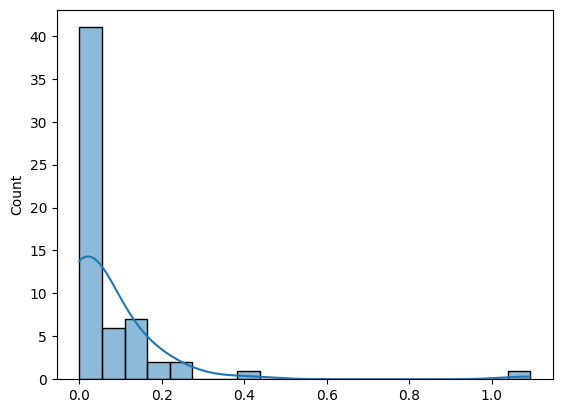

In [8]:
sns.histplot(Cs, bins = 20, kde = True)

In [ ]:
save_path = "reservoir_test/dupuit/straight_conduit/gamma_conductances_conduit_only"
adaptive_timesteps = True
steady_state = False 
output_interval = 100
dt_init = 1.0
dt_max = 100
inflow_type = 'timeseries'
head_type = 'constant'
conduit_eta = 1
fracture_eta = 0
matrix_eta = 1 - conduit_eta
total_A = 1e3
reservoirs = {
    network.diffuse_inlets[i] : {'A' : total_A/len(network.diffuse_inlets), 
                                 'S_y' : 0.15, 
                                 'h_0' : 0.001, 'C' : Cs[i], 
                                 'reservoir_recharge' : ('timeseries', recharge_time, recharge_timeseries*matrix_eta/len(network.diffuse_inlets))} 
                                 for i in range(len(network.diffuse_inlets))

}
inflow_boundary = {network.inlets : {'flow' : recharge_timeseries * conduit_eta, 'time': recharge_time}} #{network.diffuse_inlets: {'flow' : 0.1/len(network.diffuse_inlets)}} # m^3/s
head_boundary = {network.outlets: {'head' : 0.001}}
t_max= recharge_time[-1]

flow_network, results = run_reservoir_model(network, head_boundary, 
                                            inflow_boundary,
                                            reservoirs,
                                            save_path, 
                                            t_max = t_max,
                                            output_interval = 100, 
                                            data_to_save = ['input_data', 'observation_data', 'flowrates', 'reynolds_numbers', 'water_depths', 'time'], 
                                            observation_nodes = [network.inlets[0], network.outlets[0]],
                                            steady_state = steady_state,
                                            inflow_type = inflow_type,
                                            head_type = head_type)

Timestep = 0, Time = 0.0, dt = 1.00e+00
Converged = True, Picard iterations = 9, convergence fails = 0
relL2(y) = 4.42e-01, relL2(Q) = 1.00e+00
Max Froude = 0.95
Max Re = 1103.46 Avg Re = 82.64

Timestep = 10000, Time = 10005.0, dt = 1.00e+00
Converged = True, Picard iterations = 1, convergence fails = 0
relL2(y) = 3.30e-07, relL2(Q) = 7.26e-07
Max Froude = 1.33
Max Re = 151857.30 Avg Re = 131255.21

Timestep = 20000, Time = 20005.0, dt = 1.00e+00
Converged = True, Picard iterations = 1, convergence fails = 0
relL2(y) = 3.40e-08, relL2(Q) = 7.53e-08
Max Froude = 1.33
Max Re = 152647.37 Avg Re = 131431.97

Timestep = 30000, Time = 30005.0, dt = 1.00e+00
Converged = True, Picard iterations = 1, convergence fails = 0
relL2(y) = 1.12e-08, relL2(Q) = 2.50e-08
Max Froude = 1.33
Max Re = 152754.78 Avg Re = 131462.87

Timestep = 40000, Time = 40005.0, dt = 1.00e+00
Converged = True, Picard iterations = 1, convergence fails = 0
relL2(y) = 6.49e-09, relL2(Q) = 1.45e-08
Max Froude = 1.33
Max Re =

# Transport

In [ ]:
save_path = f"reservoir_test/transport/1D_conduit/d=1/no_reservoir"
adaptive_timesteps = True
steady_state = False 
output_interval = 100
dt_init = 1.0
dt_max = 100
inflow_type = 'constant'
head_type = 'constant'
concentration_type = 'timeseries'
conduit_eta = 1
# fracture_eta = 0.33
matrix_eta = 1 - conduit_eta
reservoirs = {
    # 10 : {'A' : 1e6, 'S_y' : 0.15, 'h_0' : .001, 'C' : 1e-4, 'reservoir_recharge' : ('timeseries', recharge_time, recharge_timeseries*matrix_eta)},
    # 15: {'A' : 1e3, 'S_y' : 0.15, 'h_0' : 1, 'C' : 1e-2, 'reservoir_recharge' : ('timeseries', recharge_time, recharge_timeseries*fracture_eta)},
}
inflow_boundary = {network.inlets : {'flow' : 0.1/len(network.inlets)}} #{network.diffuse_inlets: {'flow' : 0.1/len(network.diffuse_inlets)}} # m^3/s
head_boundary = {network.outlets: {'head' : 0.001}}
concentration_boundary = {network.inlets : {'concentration' : 1 * np.ones(5), 'time' : np.arange(1000, 5001, 1000)}}
t_max= 500000


transport_settings = {
    "molecular_diffusivity": 1e-9,
    "alpha_l": 1.0,
    "decay_rate": 0.0,
    "transport_cfl": 0.5,
}

flow_network, results = run_reservoir_model(network, head_boundary, 
                                            inflow_boundary, 
                                            concentration_boundary,
                                            reservoirs,
                                            save_path, 
                                            t_max = t_max,
                                            output_interval = 100, 
                                            data_to_save = ['input_data', 'observation_data', 'flowrates', 'reynolds_numbers', 'water_depths', 'time', 'concentrations'], 
                                            observation_nodes = list(network.inlets + network.outlets),
                                            steady_state = steady_state,
                                            inflow_type = inflow_type,
                                            concentration_type = concentration_type,
                                            head_type = head_type)
    

[run_simulation] Not converged at time = 0.0
Timestep = 0, Time = 0.0, dt = 1.00e+00
Converged = False, Picard iterations = 21, convergence fails = 1
relL2(y) = 1.00e+00, relL2(Q) = 1.00e+00
Max Froude = 0.00
Max Re = 0.00 Avg Re = 0.00

[run_simulation] Not converged at time = 1.0
[run_simulation] Not converged at time = 2.0
[run_simulation] Not converged at time = 3.0
[run_simulation] Not converged at time = 4.0
[run_simulation] Not converged at time = 5.0


C:\openKARST\reservoir_model\openkarst\src\openkarst\models\hydraulics.py:29: RuntimeWarning:

overflow encountered in power

C:\openKARST\reservoir_model\openkarst\src\openkarst\models\flow_simulation.py:2228: RuntimeWarning:

overflow encountered in divide

C:\openKARST\reservoir_model\openkarst\src\openkarst\models\flow_simulation.py:2061: RuntimeWarning:

overflow encountered in multiply

C:\openKARST\reservoir_model\openkarst\src\openkarst\models\flow_simulation.py:2206: RuntimeWarning:

overflow encountered in add



ValueError: cannot convert float NaN to integer

In [59]:
index = {'low_anastomotic' : 'conduits/networks/n_1', 
         'high_anastomotic' : 'conduits/networks/n_5', 
         'anastomotic_2' : 'conduits/networks/n_4',
         'branching_straight_network' : 'conduit_geometry_test/networks/branching_straight_network',
        'branching_straight_network_2D' : 'conduit_geometry_test/networks/branching_straight_network_2D',
         '1D_conduit' : 'conduit_geometry_test/networks/straight_conduit_n62',
         }
Q_bf = 0.1
for network_name in index.keys():
    #set up and load network
    network_dir = index[network_name]
    nodes = pd.read_csv(f'{network_dir}/nodes.csv')
    edges = pd.read_csv(f'{network_dir}/edges.csv')
    nodes, edges = reset_node_ids(nodes, edges)
    network = OKN(nodes = nodes, edges= edges)        
    network.extract_boundary_nodes()
    Q_per_inlet = Q_bf/len(network.inlets) 
    d_crit = calculate_pressurized_diameter(Q = Q_per_inlet, dh_dl = calculate_head_gradient(nodes, inlet_d = 0.5, inlet_flag = 'inlet', outlet_flag = 'outlet'), Re = 2300)
    d_crit = np.round(d_crit, 2)
    ds = {'unpressurized' : d_crit * 1.3,
          'pressurized' :d_crit * 0.8,}
    # network_dir = 'conduit_geometry_test/networks/straight_conduit_n62'
    for regime, d in ds.items():
        save_path = f"reservoir_test/transport/single_pulse_1/{network_name}/{regime}/no_reservoir"
        # if os.path.exists(f"{save_path}/results.npz"):
        #     print_verbose(f"{save_path} already exists, skipping")
            # continue
        network.load_cave_data(d = d)
        network.extract_edge_coordinates()
        adaptive_timesteps = True
        steady_state = False 
        output_interval = 100
        dt_init = 1.0
        dt_max = 100
        inflow_type = 'constant'
        head_type = 'constant'
        concentration_type = 'timeseries'
        conduit_eta = 1
        # fracture_eta = 0.33
        matrix_eta = 1 - conduit_eta
        reservoirs = {
            # 10 : {'A' : 1e6, 'S_y' : 0.15, 'h_0' : .001, 'C' : 1e-4, 'reservoir_recharge' : ('timeseries', recharge_time, recharge_timeseries*matrix_eta)},
            # 15: {'A' : 1e3, 'S_y' : 0.15, 'h_0' : 1, 'C' : 1e-2, 'reservoir_recharge' : ('timeseries', recharge_time, recharge_timeseries*fracture_eta)},
        }
        inflow_boundary = {network.inlets : {'flow' : Q_bf/len(network.inlets)}} #{network.diffuse_inlets: {'flow' : 0.1/len(network.diffuse_inlets)}} # m^3/s
        head_boundary = {network.outlets: {'head' : 0.001}}
        concentration_timeseries = np.array([1, 0])/len(network.inlets) #NOTE!! This is kg/s (mass injection) not concentration injection 
        concentration_time = np.array([10000,10001])
        concentration_boundary = {network.inlets : {'concentration' : concentration_timeseries, 'time' : concentration_time}}
        t_max= 500000


        transport_settings = {
            "molecular_diffusivity": 1e-9,
            "alpha_l": 1.0,
            "decay_rate": 0.0,
            "transport_cfl": 0.5,
        }

        flow_network, results = run_reservoir_model(network, head_boundary, 
                                                    inflow_boundary, 
                                                    concentration_boundary,
                                                    reservoirs,
                                                    save_path, 
                                                    t_max = t_max,
                                                    output_interval = 100, 
                                                    data_to_save = ['input_data', 'observation_data', 'flowrates', 'reynolds_numbers', 'water_depths', 'time', 'concentrations'], 
                                                    observation_nodes = list(network.inlets + network.outlets),
                                                    steady_state = steady_state,
                                                    inflow_type = inflow_type,
                                                    concentration_type = concentration_type,
                                                    head_type = head_type)
    

    

[run_simulation] Not converged at time = 0.0
Timestep = 0, Time = 0.0, dt = 1.00e+00
Converged = False, Picard iterations = 21, convergence fails = 1
relL2(y) = 8.07e-01, relL2(Q) = 1.00e+00
Max Froude = 0.72
Max Re = 2647.62 Avg Re = 59.64

[run_simulation] Not converged at time = 1326.4
[run_simulation] Not converged at time = 1391.4
[run_simulation] Not converged at time = 1443.4
[run_simulation] Not converged at time = 1484.4
[run_simulation] Not converged at time = 1493.4
[run_simulation] Not converged at time = 1502.4
[run_simulation] Not converged at time = 1518.4
[run_simulation] Not converged at time = 1532.4
[run_simulation] Not converged at time = 1545.4
[run_simulation] Not converged at time = 1556.4
[run_simulation] Not converged at time = 1557.4
[run_simulation] Not converged at time = 1566.4
[run_simulation] Not converged at time = 1575.4
[run_simulation] Not converged at time = 1578.4
[run_simulation] Not converged at time = 1585.4
[run_simulation] Not converged at time

C:\openKARST\reservoir_model\openkarst\src\openkarst\models\flow_simulation.py:2939: RuntimeWarning:

overflow encountered in expm1



[run_simulation] Not converged at time = 50.7
[run_simulation] Not converged at time = 56.7
[run_simulation] Not converged at time = 71.7
[run_simulation] Not converged at time = 80.7
[run_simulation] Not converged at time = 83.7
[run_simulation] Not converged at time = 100.7
[run_simulation] Not converged at time = 101.7
[run_simulation] Not converged at time = 135.7
[run_simulation] Not converged at time = 141.7
[run_simulation] Not converged at time = 144.7
[run_simulation] Not converged at time = 192.7
[run_simulation] Not converged at time = 213.7
[run_simulation] Not converged at time = 304.7
[run_simulation] Not converged at time = 315.7
[run_simulation] Not converged at time = 334.7
[run_simulation] Not converged at time = 357.7
[run_simulation] Not converged at time = 418.7
[run_simulation] Not converged at time = 458.7
[run_simulation] Not converged at time = 463.7
[run_simulation] Not converged at time = 478.7
[run_simulation] Not converged at time = 499.7
[run_simulation] N

C:\openKARST\reservoir_model\openkarst\src\openkarst\models\flow_simulation.py:2939: RuntimeWarning:

overflow encountered in expm1



[run_simulation] Not converged at time = 56.7
[run_simulation] Not converged at time = 71.7
[run_simulation] Not converged at time = 80.7
[run_simulation] Not converged at time = 83.7
[run_simulation] Not converged at time = 100.7
[run_simulation] Not converged at time = 101.7
[run_simulation] Not converged at time = 135.7
[run_simulation] Not converged at time = 141.7
[run_simulation] Not converged at time = 144.7
[run_simulation] Not converged at time = 192.7
[run_simulation] Not converged at time = 213.7
[run_simulation] Not converged at time = 304.7
[run_simulation] Not converged at time = 315.7
[run_simulation] Not converged at time = 334.7
[run_simulation] Not converged at time = 357.7
[run_simulation] Not converged at time = 418.7
[run_simulation] Not converged at time = 458.7
[run_simulation] Not converged at time = 463.7
[run_simulation] Not converged at time = 478.7
[run_simulation] Not converged at time = 499.7
[run_simulation] Not converged at time = 517.7
[run_simulation] 

C:\openKARST\reservoir_model\openkarst\src\openkarst\models\flow_simulation.py:2939: RuntimeWarning:

overflow encountered in expm1



[run_simulation] Not converged at time = 1330.7
[run_simulation] Not converged at time = 1332.7
[run_simulation] Not converged at time = 1338.7
[run_simulation] Not converged at time = 1539.7
[run_simulation] Not converged at time = 1569.7
[run_simulation] Not converged at time = 1637.7
[run_simulation] Not converged at time = 1796.7
[run_simulation] Not converged at time = 2035.7
[run_simulation] Not converged at time = 2109.7
[run_simulation] Not converged at time = 2231.7
[run_simulation] Not converged at time = 2341.7
[run_simulation] Not converged at time = 2548.7
[run_simulation] Not converged at time = 2571.7
[run_simulation] Not converged at time = 2664.7
[run_simulation] Not converged at time = 2715.7
[run_simulation] Not converged at time = 2999.7
[run_simulation] Not converged at time = 3020.7
[run_simulation] Not converged at time = 3323.7
[run_simulation] Not converged at time = 3400.7
[run_simulation] Not converged at time = 3447.7
[run_simulation] Not converged at time =

C:\openKARST\reservoir_model\openkarst\src\openkarst\models\flow_simulation.py:2939: RuntimeWarning:

overflow encountered in expm1



[run_simulation] Not converged at time = 1330.7
[run_simulation] Not converged at time = 1332.7
[run_simulation] Not converged at time = 1338.7
[run_simulation] Not converged at time = 1539.7
[run_simulation] Not converged at time = 1569.7
[run_simulation] Not converged at time = 1637.7
[run_simulation] Not converged at time = 1796.7
[run_simulation] Not converged at time = 2035.7
[run_simulation] Not converged at time = 2109.7
[run_simulation] Not converged at time = 2231.7
[run_simulation] Not converged at time = 2341.7
[run_simulation] Not converged at time = 2548.7
[run_simulation] Not converged at time = 2571.7
[run_simulation] Not converged at time = 2664.7
[run_simulation] Not converged at time = 2715.7
[run_simulation] Not converged at time = 2999.7
[run_simulation] Not converged at time = 3020.7
[run_simulation] Not converged at time = 3323.7
[run_simulation] Not converged at time = 3400.7
[run_simulation] Not converged at time = 3447.7
[run_simulation] Not converged at time =

In [ ]:
save_path = "reservoir_test/transport/anastomotic_2/d=1/no_reservoir"
adaptive_timesteps = True
steady_state = False 
output_interval = 100
dt_init = 1.0
dt_max = 100
inflow_type = 'constant'
head_type = 'constant'
concentration_type = 'timeseries'
conduit_eta = 1
# fracture_eta = 0.33
matrix_eta = 1 - conduit_eta
reservoirs = {
    # 10 : {'A' : 1e6, 'S_y' : 0.15, 'h_0' : .001, 'C' : 1e-4, 'reservoir_recharge' : ('timeseries', recharge_time, recharge_timeseries*matrix_eta)},
    # 15: {'A' : 1e3, 'S_y' : 0.15, 'h_0' : 1, 'C' : 1e-2, 'reservoir_recharge' : ('timeseries', recharge_time, recharge_timeseries*fracture_eta)},
}
concentration_timeseries = np.array([1, 0])/len(network.inlets)
concentration_time = np.array([10000,10001])
inflow_boundary = {network.inlets : {'flow' : 0.1}} #{network.diffuse_inlets: {'flow' : 0.1/len(network.diffuse_inlets)}} # m^3/s
head_boundary = {network.outlets: {'head' : 0.001}}
concentration_boundary = {network.inlets : {'concentration' : concentration_timeseries, 'time' : concentration_time}}
t_max= 500000


transport_settings = {
    "molecular_diffusivity": 1e-9,
    "alpha_l": 1.0,
    "decay_rate": 0.0,
    "transport_cfl": 0.5,
}

flow_network, results = run_reservoir_model(network, head_boundary, 
                                            inflow_boundary, 
                                            concentration_boundary,
                                            reservoirs,
                                            save_path, 
                                            t_max = t_max,
                                            output_interval = 100, 
                                            data_to_save = ['input_data', 'observation_data', 'flowrates', 'reynolds_numbers', 'water_depths', 'time', 'concentrations'], 
                                            observation_nodes = list(network.inlets + network.outlets),
                                            steady_state = steady_state,
                                            inflow_type = inflow_type,
                                            concentration_type = concentration_type,
                                            head_type = head_type)

[run_simulation] Not converged at time = 0.0
Timestep = 0, Time = 0.0, dt = 1.00e+00
Converged = False, Picard iterations = 21, convergence fails = 1
relL2(y) = 7.73e-01, relL2(Q) = 1.00e+00
Max Froude = 0.72
Max Re = 4543.98 Avg Re = 33.24

Timestep = 10000, Time = 10000.4, dt = 1.00e+00
Converged = True, Picard iterations = 6, convergence fails = 1
relL2(y) = 8.04e-05, relL2(Q) = 7.01e-05
Max Froude = 1.16
Max Re = 315035.01 Avg Re = 105843.19

Timestep = 20000, Time = 20000.4, dt = 1.00e+00
Converged = True, Picard iterations = 5, convergence fails = 1
relL2(y) = 3.07e-05, relL2(Q) = 4.21e-05
Max Froude = 1.84
Max Re = 961259.19 Avg Re = 94083.44

Timestep = 30000, Time = 30000.4, dt = 1.00e+00
Converged = True, Picard iterations = 4, convergence fails = 1
relL2(y) = 1.78e-05, relL2(Q) = 2.66e-05
Max Froude = 2.07
Max Re = 1438267.95 Avg Re = 97208.78

Timestep = 40000, Time = 40000.4, dt = 1.00e+00
Converged = True, Picard iterations = 4, convergence fails = 1
relL2(y) = 1.23e-05, 

## Sensitivity Analysis

In [4]:
#set up and load network
network_dir = 'conduit_geometry_test/networks/straight_conduit_n62'
nodes = pd.read_csv(f'{network_dir}/nodes.csv')
edges = pd.read_csv(f'{network_dir}/edges.csv')
nodes, edges = reset_node_ids(nodes, edges)
# network_dir = 'conduit_geometry_test/networks/straight_conduit_n62'
network = OKN(nodes = nodes, edges= edges, diameters = 0.5) 
network.load_cave_data()
network.extract_edge_coordinates()
network.extract_boundary_nodes()
network.extract_diffuse_inlets()
network.plot_3D_network(node_color = 'type')


In [ ]:
"""Scenarios
Sensitivity to C, A, S_y 
"""

In [78]:
recharge = pd.read_csv("reservoir_test/gaussian_pulse_10_day.csv")
recharge['time'] = recharge.time - recharge.time.min() + 43200+3600

In [79]:
temp = pd.DataFrame(data = {'time': np.arange(0, 43201, 3600), 'recharge' : 0.02 *np.ones(len(np.arange(0, 43201, 3600)))})
final_temp = pd.concat([temp, recharge], axis = 0)
# final_temp.to_csv('reservoir_test/gaussian_short_spinup_pulse_only')

In [6]:
Cs = [1e-1]
As = [1e6]
S_y = [0.01, 0.5]
reservoir_configs = [(10,), tuple(range(10,55, 5)), tuple(range(10,55, 10))]
conduit_etas = [1, 0.5, 0]
recharge = pd.read_csv("reservoir_test/gaussian_pulse_5_day.csv")
recharge_timeseries = recharge.recharge.values / 2 * 5 
recharge_time = recharge.time.values

t_max= recharge_time[-1]
steady_state = False
inflow_type = 'timeseries'
Q_in = 0.1
head_type = 'constant'
base_dir = 'reservoir_test/sensitivity_gaussian_high_flow'
for reservoir_nodes in reservoir_configs:
    reservoir_label = reservoir_nodes if len(reservoir_nodes) <=3 else len(reservoir_nodes)
    for A in As:
        for S in S_y:
            for C in Cs:
                for conduit_eta in conduit_etas:
                    print(f"Processing {reservoir_nodes} with conduit_eta {conduit_eta}")
                    save_path = f'{base_dir}/A_{A}/S_y_{S}/C_{C}/reservoirs_{reservoir_label}/conduit_eta_{conduit_eta}'
                    matrix_eta = 1 - conduit_eta
                    # inflow_boundary = {network.inlets : {'flow' : Q_in/len(network.inlets) * conduit_eta}}
                    inflow_boundary = {network.inlets : {'flow' : (recharge_timeseries * conduit_eta)/len(network.inlets), 'time': recharge_time}} 
                    head_boundary = {network.outlets: {'head' : 0.001}}
                    reservoirs = {
                        node : {'A' : A/len(reservoir_nodes), 
                                'S_y' : S, 
                                'h_0' : 0.001, 'C' : C, 
                                'reservoir_recharge' : ('timeseries', recharge_time, recharge_timeseries*matrix_eta/len(reservoir_nodes)) 
                                #  Q_in * matrix_eta/ len(reservoir_nodes) #
                                }
                                for node in reservoir_nodes 
}
                    try: 
                        flow_network, results = run_reservoir_model(network, head_boundary, 
                                                inflow_boundary, 
                                                {},
                                                reservoirs,
                                                save_path, 
                                                t_max = t_max,
                                                output_interval = 100, 
                                                data_to_save = ['input_data', 'observation_data', 'flowrates', 'reynolds_numbers', 'water_depths', 'time', 
                            
                                                                'velocities'], 
                                                observation_nodes = list(network.inlets + network.outlets + reservoir_nodes),
                                                steady_state = False,
                                                inflow_type = inflow_type,
                                                # concentration_type = concentration_type,
                                                head_type = head_type)
                        print(f"{save_path} complete")
                    except ValueError as e:
                        print(f"Simulation failed because {e}. Skipping")
                        continue

Processing (10,) with conduit_eta 1
[run_simulation] Not converged at time = 0.0
Timestep = 0, Time = 0.0, dt = 1.00e+00
Converged = False, Picard iterations = 21, convergence fails = 1
relL2(y) = 7.46e-01, relL2(Q) = 1.00e+00
Max Froude = 1.00
Max Re = 3233.07 Avg Re = 115.49

Timestep = 10000, Time = 10001.1, dt = 1.00e+00
Converged = True, Picard iterations = 1, convergence fails = 1
relL2(y) = 1.00e-06, relL2(Q) = 1.34e-06
Max Froude = 1.48
Max Re = 328171.01 Avg Re = 266639.79

Timestep = 20000, Time = 20001.1, dt = 1.00e+00
Converged = True, Picard iterations = 2, convergence fails = 1
relL2(y) = 1.40e-06, relL2(Q) = 3.41e-06
Max Froude = 1.48
Max Re = 327409.08 Avg Re = 271198.98

Timestep = 30000, Time = 30001.1, dt = 1.00e+00
Converged = True, Picard iterations = 1, convergence fails = 1
relL2(y) = 1.00e-06, relL2(Q) = 1.89e-06
Max Froude = 1.49
Max Re = 326729.36 Avg Re = 275360.63

Timestep = 40000, Time = 40001.1, dt = 1.00e+00
Converged = True, Picard iterations = 1, conve

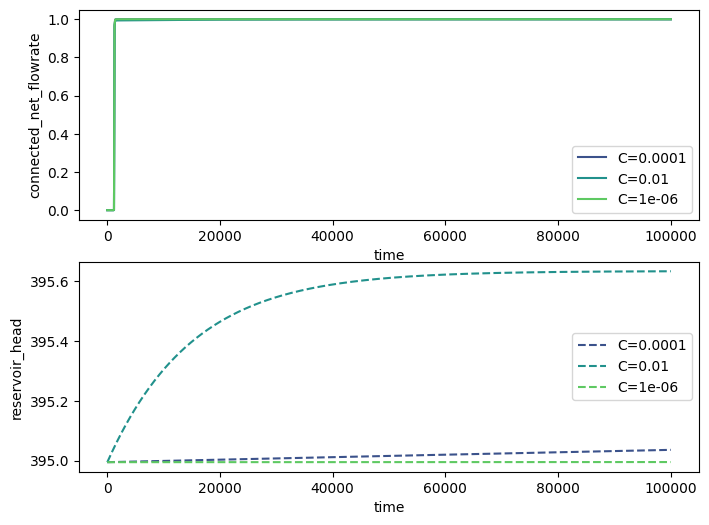

In [170]:
sensitivity_data = pd.DataFrame(columns = ['C', 'Q_ss'])
fig, ax = plt.subplots(2,1, figsize = (8,6))
colors = sns.color_palette("viridis", n_colors=len(os.listdir('reservoir_test/sensitivity_conduit_recharge')))
i = 0
for dir in os.listdir('reservoir_test/sensitivity_conduit_recharge'):
    C = float(dir.split('_')[1])
    try:
        obs_df = pd.read_csv(f'reservoir_test/sensitivity_conduit_recharge/{dir}/observation_data_0.csv')
        res_df = pd.read_csv(f'reservoir_test/sensitivity_conduit_recharge/{dir}/observation_data_1.csv')
        sns.lineplot(x = obs_df['time'], y = obs_df['connected_net_flowrate'], color = colors[i], label = f'C={C}', ax = ax[0])
        sns.lineplot(x = res_df['time'], y = res_df['reservoir_head'],  color = colors[i], label = f'C={C}', ax = ax[1], linestyle = '--')
        i+=1
    except FileNotFoundError:
        continue
    Q_ss = obs_df['connected_net_flowrate'].iloc[-1]
    sensitivity_data.loc[sensitivity_data.shape[0]] = [C, Q_ss]


Text(0, 0.5, 'Steady-state outflow ($m^3$/s)')

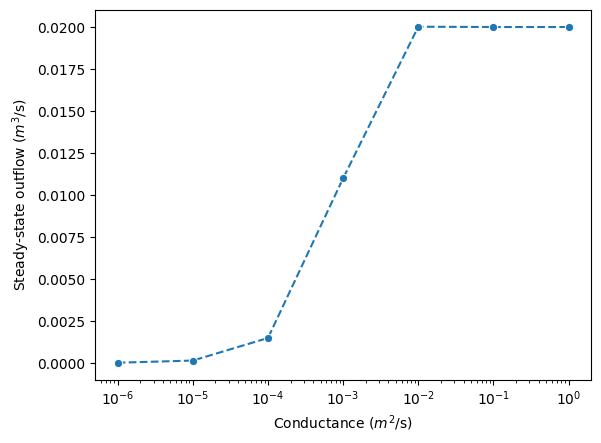

In [160]:
sns.lineplot(sensitivity_data, x = 'C',y = 'Q_ss', linestyle = '--', marker = 'o')
plt.xscale('log')
plt.xlabel(r"Conductance ($m^2$/s)")
plt.ylabel(r"Steady-state outflow ($m^3$/s)")

## Visualization

In [2]:
data_path_control = 'reservoir_test/dupuit/straight_conduit/no_reservoir'
results_control = np.load(f'{data_path_control}/results.npz')
input_data_control = load_pickle(f'{data_path_control}/input_data.pkl')

obs_df_control = pd.read_csv(f'{data_path_control}/observation_data.csv')
# reservoir_df = pd.read_csv(f'{data_path_control}/observation_data_1.csv')


In [3]:
data_path_an = 'reservoir_test/anastomotic/single_reservoir_1e-4'
results_an = np.load(f'{data_path_an}/results.npz')
input_data_an = load_pickle(f'{data_path_an}/input_data.pkl')

obs_df_an = pd.read_csv(f'{data_path_an}/observation_data.csv')


In [60]:
data_path_an_d_1 = 'reservoir_test/anastomotic/d=1/reservoir_conduit_recharge'
results_an_d_1 = np.load(f'{data_path_an_d_1}/results.npz')
input_data_an_d_1 = load_pickle(f'{data_path_an_d_1}/input_data.pkl')

obs_df_an_d_1 = pd.read_csv(f'{data_path_an_d_1}/observation_data.csv')

In [8]:
data_path_pulse_only = 'reservoir_test/anastomotic/C=1e-4/reservoir_pulse_only'
results_pulse_only = np.load(f'{data_path_pulse_only}/results.npz')
input_data_pulse_only = load_pickle(f'{data_path_pulse_only}/input_data.pkl')
obs_df_pulse_only = pd.read_csv(f'{data_path_pulse_only}/observation_data.csv')

In [ ]:
data_path_low_pulse_only = 'reservoir_test/low_anastomotic/C=1e-4/reservoir_pulse_only'
results_low_pulse_only = np.load(f'{data_path_low_pulse_only}/results.npz')
input_data_low_pulse_only = load_pickle(f'{data_path_low_pulse_only}/input_data.pkl')
obs_df_low_pulse_only = pd.read_csv(f'{data_path_low_pulse_only}/observation_data.csv')

In [15]:
data_path_low_pulse_only_d_1 = 'reservoir_test/low_anastomotic/C=1e-4/d=1/reservoir_pulse_only'
results_low_pulse_only_d_1 = np.load(f'{data_path_low_pulse_only_d_1}/results.npz')
input_data_low_pulse_only_d_1 = load_pickle(f'{data_path_low_pulse_only_d_1}/input_data.pkl')
obs_df_low_pulse_only_d_1 = pd.read_csv(f'{data_path_low_pulse_only_d_1}/observation_data.csv')

In [21]:
data_path_pulse_only_d_1 = 'reservoir_test/low_anastomotic/C=1e-4/d=1/reservoir_pulse_only'
results_pulse_only_d_1 = np.load(f'{data_path_pulse_only_d_1}/results.npz')
input_data_pulse_only_d_1 = load_pickle(f'{data_path_pulse_only_d_1}/input_data.pkl')
obs_df_pulse_only_d_1 = pd.read_csv(f'{data_path_pulse_only_d_1}/observation_data.csv')

In [104]:
data_path_an_high_C = 'reservoir_test/anastomotic/C=1e-2/reservoir_conduit_recharge'
results_an_high_C = np.load(f'{data_path_an_high_C}/results.npz')
input_data_an_high_C = load_pickle(f'{data_path_an_high_C}/input_data.pkl')

obs_df_an_high_C = pd.read_csv(f'{data_path_an_high_C}/observation_data.csv')

In [76]:
data_path_conan_1 = 'reservoir_test/anastomotic/reservoir_conduit_recharge'
results_conan_1 = np.load(f'{data_path_conan_1}/results.npz')
input_data_conan_1 = load_pickle(f'{data_path_conan_1}/input_data.pkl')

obs_df_conan_1 = pd.read_csv(f'{data_path_conan_1}/observation_data.csv')

In [68]:
data_path_an_d_1_1 = 'reservoir_test/anastomotic/d=1/no_reservoir'
results_an_d_1_1 = np.load(f'{data_path_an_d_1_1}/results.npz')
input_data_an_d_1_1 = load_pickle(f'{data_path_an_d_1_1}/input_data.pkl')

obs_df_an_d_1_1 = pd.read_csv(f'{data_path_an_d_1_1}/observation_data.csv')

In [4]:
data_path_conan = 'reservoir_test/low_anastomotic/reservoir_conduit_recharge'
results_conan = np.load(f'{data_path_conan}/results.npz')
input_data_conan = load_pickle(f'{data_path_conan}/input_data.pkl')

obs_df_conan = pd.read_csv(f'{data_path_conan}/observation_data.csv')

In [5]:
data_path_lan = 'reservoir_test/low_anastomotic/single_reservoir_1e-4'
results_lan = np.load(f'{data_path_lan}/results.npz')
input_data_lan = load_pickle(f'{data_path_lan}/input_data.pkl')

obs_df_lan = pd.read_csv(f'{data_path_lan}/observation_data.csv')
# reservoir_df = pd.read_csv(f'{data_path_lan}/observation_data_1.csv')

In [6]:
data_path_lan_1= 'reservoir_test/low_anastomotic/no_reservoir'
results_lan_1 = np.load(f'{data_path_lan_1}/results.npz')
input_data_lan_1 = load_pickle(f'{data_path_lan_1}/input_data.pkl')

obs_df_lan_1 = pd.read_csv(f'{data_path_lan_1}/observation_data.csv')

In [7]:
data_path_an_1= 'reservoir_test/anastomotic/no_reservoir'
results_an_1 = np.load(f'{data_path_an_1}/results.npz')
input_data_an_1 = load_pickle(f'{data_path_an_1}/input_data.pkl')

obs_df_an_1 = pd.read_csv(f'{data_path_an_1}/observation_data.csv')

In [36]:
data_path = 'reservoir_test/straight_conduit/multi_reservoirs'
results = np.load(f'{data_path}/results.npz')
input_data = load_pickle(f'{data_path}/input_data.pkl')

obs_df = pd.read_csv(f'{data_path}/observation_data.csv')
# reservoir_df = pd.read_csv(f'{data_path}/observation_data_1.csv')


In [37]:
data_path_2 = 'reservoir_test/straight_conduit/uniform_reservoirs'
results_2 = np.load(f'{data_path_2}/results.npz')
input_data_2 = load_pickle(f'{data_path_2}/input_data.pkl')

obs_df_2 = pd.read_csv(f'{data_path_2}/observation_data.csv')

In [38]:
data_path_3 = 'reservoir_test/straight_conduit/single_reservoir_1e-4'
results_3 = np.load(f'{data_path_3}/results.npz')
input_data_3 = load_pickle(f'{data_path_3}/input_data.pkl')

obs_df_3 = pd.read_csv(f'{data_path_3}/observation_data.csv')

In [40]:
data_path_4 = 'reservoir_test/straight_conduit/gaussian_partitioned'
results_4 = np.load(f'{data_path_4}/results.npz')
input_data_4 = load_pickle(f'{data_path_4}/input_data.pkl')

obs_df_4 = pd.read_csv(f'{data_path_4}/observation_data_0.csv')

In [41]:
data_path_5 = 'reservoir_test/straight_conduit/uniform_reservoirs_low_C'
results_5 = np.load(f'{data_path_5}/results.npz')
input_data_5 = load_pickle(f'{data_path_5}/input_data.pkl')

obs_df_5 = pd.read_csv(f'{data_path_5}/observation_data.csv')

In [42]:
data_path_6 = 'reservoir_test/straight_conduit/conduit_recharge_only'
results_6 = np.load(f'{data_path_6}/results.npz')
input_data_6 = load_pickle(f'{data_path_6}/input_data.pkl')

obs_df_6 = pd.read_csv(f'{data_path_6}/observation_data.csv')

In [43]:
data_path_7 = 'reservoir_test/straight_conduit/conduit_recharge_high_flow'
results_7 = np.load(f'{data_path_7}/results.npz')
input_data_7 = load_pickle(f'{data_path_7}/input_data.pkl')

obs_df_7 = pd.read_csv(f'{data_path_7}/observation_data.csv')

In [44]:
data_path_8 = 'reservoir_test/straight_conduit/gamma_conductances'
results_8 = np.load(f'{data_path_8}/results.npz')
input_data_8 = load_pickle(f'{data_path_8}/input_data.pkl')

obs_df_8 = pd.read_csv(f'{data_path_8}/observation_data.csv')

In [45]:
data_path_9 = 'reservoir_test/straight_conduit/gamma_conductances_conduit_recharge'
results_9 = np.load(f'{data_path_9}/results.npz')
input_data_9 = load_pickle(f'{data_path_9}/input_data.pkl')

obs_df_9 = pd.read_csv(f'{data_path_9}/observation_data.csv')

In [46]:
data_path_10 = 'reservoir_test/straight_conduit/low_gamma_conductances_conduit_recharge'
results_10 = np.load(f'{data_path_10}/results.npz')
input_data_10 = load_pickle(f'{data_path_10}/input_data.pkl')

obs_df_10 = pd.read_csv(f'{data_path_10}/observation_data.csv')

In [47]:
data_path_11 = 'reservoir_test/straight_conduit/low_gamma_conductances'
results_11 = np.load(f'{data_path_11}/results.npz')
input_data_11 = load_pickle(f'{data_path_11}/input_data.pkl')

obs_df_11 = pd.read_csv(f'{data_path_11}/observation_data.csv')

In [48]:
data_path_12 = 'reservoir_test/dupuit/straight_conduit/gamma_conductances'
results_12 = np.load(f'{data_path_12}/results.npz')
input_data_12 = load_pickle(f'{data_path_12}/input_data.pkl')

obs_df_12 = pd.read_csv(f'{data_path_12}/observation_data.csv')

In [49]:
data_path_13 = 'reservoir_test/dupuit/straight_conduit/single_reservoir_1e-4'
results_13 = np.load(f'{data_path_13}/results.npz')
input_data_13 = load_pickle(f'{data_path_13}/input_data.pkl')

obs_df_13 = pd.read_csv(f'{data_path_13}/observation_data.csv')

In [50]:
data_path_14 = 'reservoir_test/dupuit/straight_conduit/gamma_conductances_conduit_only'
results_14 = np.load(f'{data_path_14}/results.npz')
input_data_14 = load_pickle(f'{data_path_14}/input_data.pkl')

obs_df_14 = pd.read_csv(f'{data_path_14}/observation_data.csv')

In [172]:
Cs = np.zeros(len(network.nodes))
for node, reservoir in input_data_11['reservoirs'].items():
    Cs[node] = reservoir['C']

(<matplotlib.collections.LineCollection at 0x1a24620d040>, None)

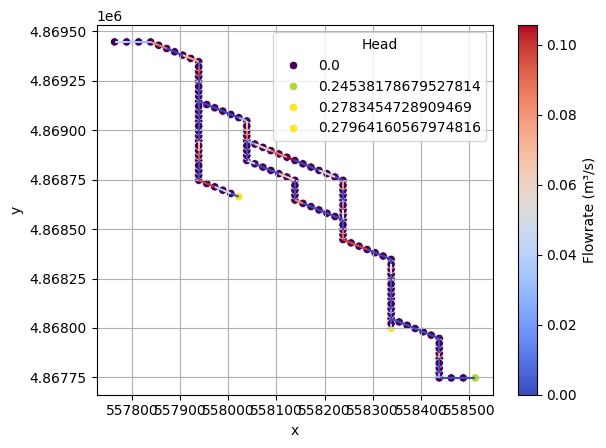

In [ ]:
network.plot_network_flow(np.abs(results_transport['flowrates'][9]), results_transport['concentrations'][9])

<Axes: xlabel='time', ylabel='reservoir_exchange'>

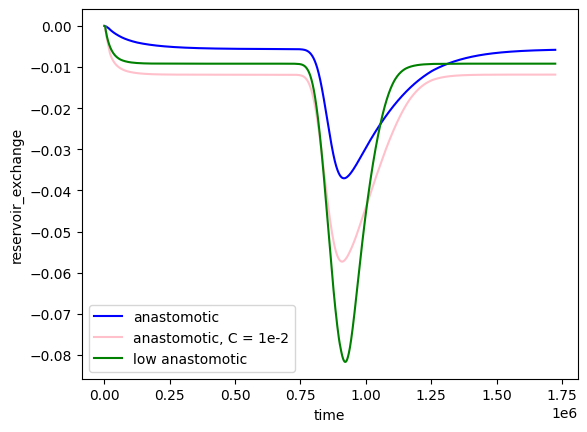

In [106]:
# sns.lineplot(data = obs_df_conan, x = 'time', y = 'reservoir_storage', color = 'orange', label = 'low anastomotic')
# sns.lineplot(data = obs_df_an, x = 'time', y = 'reservoir_storage', color = 'blue', label = 'anastomotic')
sns.lineplot(data = obs_df_conan_1, x = 'time', y = 'reservoir_exchange', color = 'blue', label = 'anastomotic')
sns.lineplot(data = obs_df_an_high_C, x = 'time', y = 'reservoir_exchange', color = 'pink', label = 'anastomotic, C = 1e-2')
sns.lineplot(data = obs_df_conan, x = 'time', y = 'reservoir_exchange', color = 'green', label = 'low anastomotic')


<Axes: xlabel='time', ylabel='reservoir_exchange'>

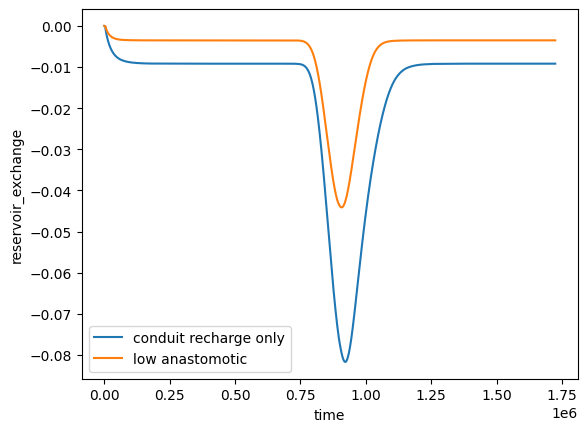

In [181]:
sns.lineplot(data = obs_df_conan, x = 'time', y = 'reservoir_exchange', label ='conduit recharge only')
sns.lineplot(data = obs_df_lan, x = 'time', y = 'reservoir_exchange', label ='low anastomotic')


Text(0, 0.5, 'Spring Q')

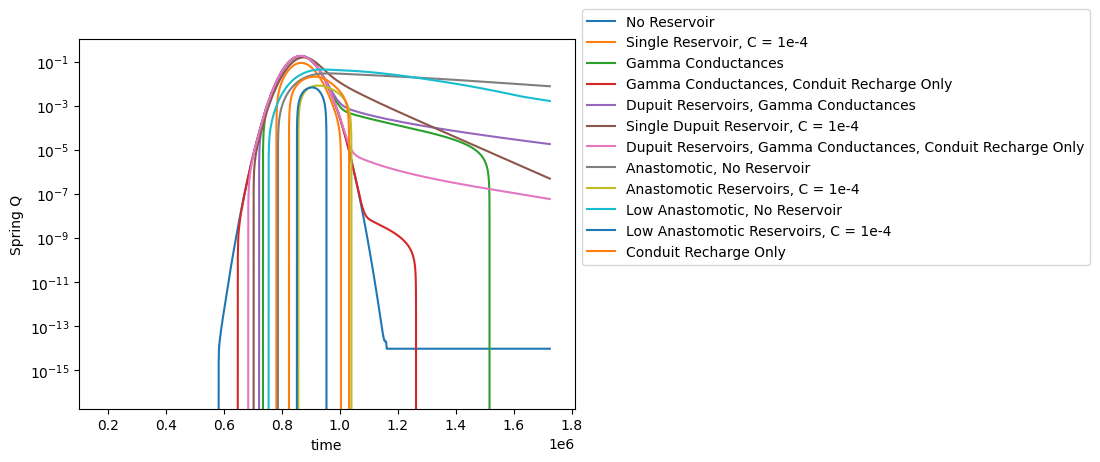

In [182]:
fig, ax = plt.subplots()
# sns.lineplot(obs_df[obs_df.node == network['outlets'][0]], x = 'time', y =obs_df['connected_net_flowrate']-0.02, ax = ax, label = 'Dual Fracture Matrix Reservoirs', color ='pink')
# sns.lineplot(obs_df_2[obs_df_2.node == network['outlets'][0]], x = 'time', y =obs_df_2['connected_net_flowrate']-0.02, ax = ax, label = 'Uniform Distributed Reservoirs')
# sns.lineplot(obs_df_4[obs_df_4.node == network['outlets'][0]], x = 'time', y =obs_df_4['connected_net_flowrate']-0.02, ax = ax, label = 'Single Reservoir, C = 1e-2')
sns.lineplot(obs_df_control[obs_df_control.node ==input_data_control['outlets'][0]], x = 'time', y =obs_df_control['connected_net_flowrate']-0.02, ax = ax, label = 'No Reservoir')
sns.lineplot(obs_df_3[obs_df_3.node == input_data_3['outlets'][0]], x = 'time', y =obs_df_3['connected_net_flowrate']-0.02, ax = ax, label = 'Single Reservoir, C = 1e-4')

# sns.lineplot(obs_df_5[obs_df_5.node == network['outlets'][0]], x = 'time', y =obs_df_5['connected_net_flowrate']-0.02, ax = ax, label = 'Uniform Reservoirs, C = 1e-4')
# sns.lineplot(obs_df_6[obs_df_6.node == network['outlets'][0]], x = 'time', y =obs_df_6['connected_net_flowrate']-0.02, ax = ax, label = 'Conduit Recharge Only')
# sns.lineplot(obs_df_7[obs_df_7.node == network['outlets'][0]], x = 'time', y =obs_df_7['connected_net_flowrate']-0.2, ax = ax, label = 'Conduit Recharge Only')
sns.lineplot(obs_df_8[obs_df_8.node == input_data_8['outlets'][0]], x = 'time', y =obs_df_8['connected_net_flowrate']-0.02, ax = ax, label = 'Gamma Conductances')
sns.lineplot(obs_df_9[obs_df_9.node == input_data_9['outlets'][0]], x = 'time', y =obs_df_9['connected_net_flowrate']-0.02, ax = ax, label = 'Gamma Conductances, Conduit Recharge Only')
# sns.lineplot(obs_df_10[obs_df_10.node == network['outlets'][0]], x = 'time', y =obs_df_10['connected_net_flowrate']-0.02, ax = ax, label = 'Low Gamma Conductances, Conduit Recharge Only')
# sns.lineplot(obs_df_11[obs_df_11.node == network['outlets'][0]], x = 'time', y =obs_df_11['connected_net_flowrate']-0.02, ax = ax, label = 'Low Gamma Conductances')
sns.lineplot(obs_df_12[obs_df_12.node == input_data_12['outlets'][0]], x = 'time', y =obs_df_12['connected_net_flowrate']-0.02, ax = ax, label = 'Dupuit Reservoirs, Gamma Conductances')
sns.lineplot(obs_df_13[obs_df_13.node == input_data_13['outlets'][0]], x = 'time', y =obs_df_13['connected_net_flowrate']-0.02, ax = ax, label = 'Single Dupuit Reservoir, C = 1e-4')
sns.lineplot(obs_df_14[obs_df_14.node == input_data_14['outlets'][0]], x = 'time', y =obs_df_14['connected_net_flowrate']-0.02, ax = ax, label = 'Dupuit Reservoirs, Gamma Conductances, Conduit Recharge Only')
sns.lineplot(obs_df_an_1[obs_df_an_1.node == input_data_an_1['outlets'][0]], x = 'time', y =obs_df_an_1['connected_net_flowrate']-0.02, ax = ax, label = 'Anastomotic, No Reservoir')
sns.lineplot(obs_df_an[obs_df_an.node == input_data_an['outlets'][0]], x = 'time', y =obs_df_an['connected_net_flowrate']-0.02, ax = ax, label = 'Anastomotic Reservoirs, C = 1e-4')
sns.lineplot(obs_df_lan_1[obs_df_lan_1.node == input_data_lan_1['outlets'][0]], x = 'time', y =obs_df_lan_1['connected_net_flowrate']-0.02, ax = ax, label = 'Low Anastomotic, No Reservoir')
sns.lineplot(obs_df_lan[obs_df_lan.node == input_data_lan['outlets'][0]], x = 'time', y =obs_df_lan['connected_net_flowrate']-0.02, ax = ax, label = 'Low Anastomotic Reservoirs, C = 1e-4')
sns.lineplot(obs_df_conan[obs_df_conan.node == input_data_conan['outlets'][0]], x = 'time', y =obs_df_conan['connected_net_flowrate']-0.02, ax = ax, label = 'Conduit Recharge Only')

# plt.stackplot(results['time'], reservoir_r_interp, r_interp, labels = ['reservoir recharge', 'conduit recharge'], colors = ['blue', 'orange'], alpha = 0.5)
# sns.lineplot(x = results['time'], y = r_interp + reservoir_r_interp, ax = ax, label = 'inflow_boundary', color = 'orange')
# sns.lineplot(reservoir_df[reservoir_df.node == reservoir_nodes[0]], x = 'time', y ='reservoir_head', ax = ax.twinx(), label = 'reservoir_head', color = 'green')
# sns.lineplot(obs_df[obs_df.node == reservoir_nodes[0]], x = 'time', y ='reservoir_exchange', ax = ax, label = 'reservoir_exchange', color = 'red')
# sns.lineplot(reservoir_df[reservoir_df.node == 0], x = 'time', y ='reservoir_storage', ax = ax, label = 'reservoir_storage', color = 'orange')
plt.legend(loc = 'upper left', bbox_to_anchor=(1, 1.1))
# plt.xscale('log')
plt.yscale('log')
plt.xlim(1e5,)
plt.ylabel("Spring Q")

In [ ]:
#Check mass balance
"""
R + Q_r = Q_s + S

S = R + Q_r - Q_s 
If no reservoir, it should be R = Q_s 
"""

In [54]:
test_network = OKN(nodes = input_data_conan['nodes'], edges = input_data_conan['edges'], geometry = input_data_conan['cn_geometry'])
test_network.calculate_network_volume()

np.float64(24.73393159298307)

<Axes: xlabel='time'>

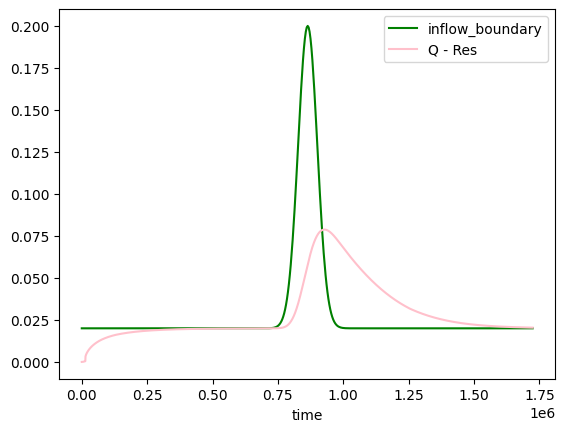

In [101]:
data = obs_df_conan_1
input_data= input_data_conan_1
res_id = list(input_data['reservoirs'].keys())[0]
R = None
inlets = list(input_data['inflow_boundary'].keys())[0]
t = input_data['inflow_boundary'][inlets]['time']
for nodes, Q_series in input_data['inflow_boundary'].items():
    if not R: 
        R = len(nodes) * Q_series['flow']
    else:
        R += len(nodes) * Q_series['flow']
sns.lineplot(x= t, y = R, color = 'green', label = 'inflow_boundary')
# sns.lineplot(data = data[data.node == input_data['outlets'][0]], x = 'time', y = 'connected_net_flowrate', label = 'spring', color = 'blue')
# sns.lineplot(data = data[data.node == res_id], x = 'time', y = 'reservoir_exchange', label = 'reservoir', color = 'orange')
sns.lineplot(x =  data[data.node == input_data['outlets'][0]]['time'], y =  data[data.node == input_data['outlets'][0]]['connected_net_flowrate'].to_numpy() - data[data.node == res_id]['reservoir_exchange'].to_numpy(), label = 'Q - Res', color = 'pink')


Text(0, 0.5, 'Spring Q')

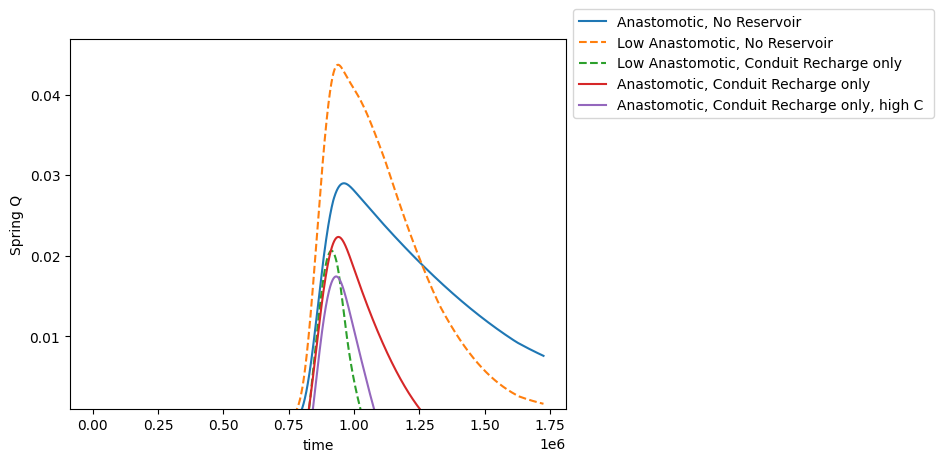

In [166]:
# sns.lineplot(obs_df_an[obs_df_an.node == input_data_an['outlets'][0]], x = 'time', y =obs_df_an['connected_net_flowrate']-0.02, label = 'Anastomotic Reservoirs, C = 1e-4')
sns.lineplot(obs_df_an_1[obs_df_an_1.node == input_data_an_1['outlets'][0]], x = 'time', y =obs_df_an_1['connected_net_flowrate']-0.02, label = 'Anastomotic, No Reservoir')
# sns.lineplot(obs_df_lan[obs_df_lan.node == input_data_lan['outlets'][0]], x = 'time', y =obs_df_lan['connected_net_flowrate']-0.02, linestyle = '--', label = 'Low Anastomotic Reservoirs, C = 1e-4')
sns.lineplot(obs_df_lan_1[obs_df_lan_1.node == input_data_lan_1['outlets'][0]], x = 'time', y =obs_df_lan_1['connected_net_flowrate']-0.02, linestyle = '--', label = 'Low Anastomotic, No Reservoir')
sns.lineplot(obs_df_conan[obs_df_conan.node == input_data_conan['outlets'][0]], x = 'time', y =obs_df_conan['connected_net_flowrate']-0.02, linestyle = '--', label = 'Low Anastomotic, Conduit Recharge only')
# sns.lineplot(obs_df_an_d_1[obs_df_an_d_1.node == input_data_an_d_1['outlets'][0]], x = 'time', y =obs_df_an_d_1['connected_net_flowrate']-0.02, label = 'Anastomotic, d = 1, Conduit Recharge only')
# sns.lineplot(obs_df_an_d_1_1[obs_df_an_d_1_1.node == input_data_an_d_1_1['outlets'][0]], x = 'time', y =obs_df_an_d_1_1['connected_net_flowrate']-0.02, label = 'Anastomotic, d = 1, No Reservoir')
sns.lineplot(obs_df_conan_1[obs_df_conan_1.node == input_data_conan_1['outlets'][0]], x = 'time', y =obs_df_conan_1['connected_net_flowrate']-0.02, label = 'Anastomotic, Conduit Recharge only')
sns.lineplot(obs_df_an_high_C[obs_df_an_high_C.node == input_data_an_high_C['outlets'][0]], x = 'time', y =obs_df_an_high_C['connected_net_flowrate']-0.02, label = 'Anastomotic, Conduit Recharge only, high C ')
# sns.lineplot(recharge_df, x = 'time', y = recharge_df['recharge']-0.02, label = 'Recharge Timeseries')
# plt.yscale('log')
# plt.xscale('log')

# plt.xlim(6e5,)
plt.ylim(1e-3,)
plt.legend(loc = 'upper left', bbox_to_anchor=(1, 1.1))
plt.ylabel("Spring Q")

(0.0, 300000.0)

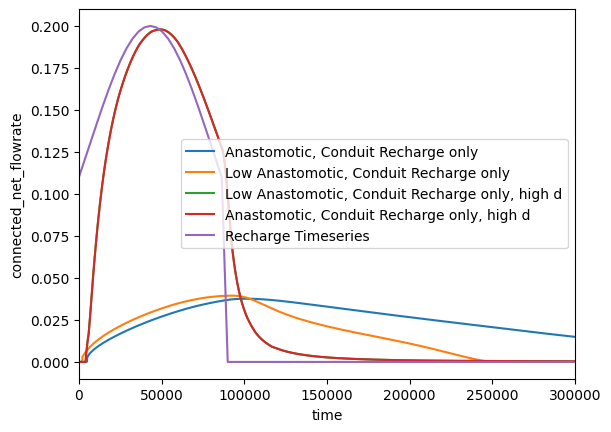

In [23]:
sns.lineplot(obs_df_pulse_only[obs_df_pulse_only.node == input_data_pulse_only['outlets'][0]], x = 'time', y =obs_df_pulse_only['connected_net_flowrate'], label = 'Anastomotic, Conduit Recharge only')
sns.lineplot(obs_df_low_pulse_only[obs_df_low_pulse_only.node == input_data_low_pulse_only['outlets'][0]], x = 'time', y =obs_df_low_pulse_only['connected_net_flowrate'], label = 'Low Anastomotic, Conduit Recharge only ')
sns.lineplot(obs_df_low_pulse_only_d_1[obs_df_low_pulse_only_d_1.node == input_data_low_pulse_only_d_1['outlets'][0]], x = 'time', y =obs_df_low_pulse_only_d_1['connected_net_flowrate'], label = 'Low Anastomotic, Conduit Recharge only, high d')
sns.lineplot(obs_df_pulse_only_d_1[obs_df_pulse_only_d_1.node == input_data_pulse_only_d_1['outlets'][0]], x = 'time', y =obs_df_pulse_only_d_1['connected_net_flowrate'], label = 'Anastomotic, Conduit Recharge only, high d')

sns.lineplot(recharge_df, x = 'time', y = recharge_df['recharge'], label = 'Recharge Timeseries')
# plt.yscale("log")
plt.xlim(0, 3e5)


net : <openpnm.network.Network at 0x1a23dde5c20>

In [145]:
#visualization
def find_free_port(start=8050):
    port = start
    while True:
        with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as sock:
            try:
                sock.bind(("0.0.0.0", port))
                return port
            except OSError:
                port += 1

viewer_port = find_free_port(8050)
# obs_df = flow_network.get_observation_dataframe()
launch_openkarst_viewer(results_transport, input_data_transport['cn_geometry'], obs_df_transport, port=viewer_port)
